In [13]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import sys
sys.path.append('../..')

from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [14]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)

def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    # PDE ztrata:
    u = model(pde_input)
    #print(u_t)
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_grad = -1 * k(pde_input) * u_grad
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]
    
    ku_x = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0]
    ku_y = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1]

    return ku_x + ku_y

def loss_fn(model: torch.nn.Module, domain: cb.CubeDomain):
    int_pts = domain.interior.requires_grad_(True)
    res = pde_residuum(int_pts, model)
    int_loss = torch.mean((res)**2)
    
    left_pts = domain.sides[0][0].requires_grad_(True)
    right_pts = domain.sides[0][1].requires_grad_(True)

    left_out, right_out = model(left_pts), model(right_pts)
    left_loss = torch.mean(left_out**2)
    right_loss = torch.mean((right_out - 1)**2)
    
    top_pts = domain.sides[1][1].requires_grad_(True)
    bot_pts = domain.sides[1][0].requires_grad_(True)
    
    top_out, bot_out = model(top_pts), model(bot_pts)
    
    top_d_dn = calc.dir_derivative(top_pts, top_out, torch.tensor([0, 1], dtype=torch.float32, device=device), False, True)
    bot_d_dn = calc.dir_derivative(bot_pts, bot_out, torch.tensor([0, -1], dtype=torch.float32, device=device), False, True)

    top_loss = torch.mean((top_d_dn - 1)**2)
    bot_loss = torch.mean((bot_d_dn - 1)**2)

    return [int_loss, left_loss, right_loss, top_loss, bot_loss]

In [15]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=2500,
    N_sides=[(500, 500), (500, 500)],
    int_sampling='Latin',
    device=device
)

domain = cb.CubeDomain(domain_ctx)

In [16]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[32, 32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model = mm.MLPModel(model_ctx).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-4)

In [17]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optim,
    domain=domain,
    loss_fn=loss_fn,
    epochs=10_000,
)

total_loss, comp_loss = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.1)

Loss at epoch 1 is: 2.8816587924957275. 
Loss at epoch 100 is: 2.3147778511047363. 
Loss at epoch 200 is: 1.6625235080718994. 
Loss at epoch 300 is: 1.0474679470062256. 
Loss at epoch 400 is: 0.7031352519989014. 
Loss at epoch 500 is: 0.44349145889282227. 
Loss at epoch 600 is: 0.19585342705249786. 
Loss at epoch 700 is: 0.09089881181716919. 
Loss at epoch 800 is: 0.06470750272274017. 
Loss at epoch 900 is: 0.055926620960235596. 
Loss at epoch 1000 is: 0.052080798894166946. 
Loss at epoch 1100 is: 0.04850137233734131. 
Loss at epoch 1200 is: 0.04662191867828369. 
Loss at epoch 1300 is: 0.043939754366874695. 
Loss at epoch 1400 is: 0.044891368597745895. 
Loss at epoch 1500 is: 0.04463160037994385. 
Loss at epoch 1600 is: 0.04309537634253502. 
Loss at epoch 1700 is: 0.04365966096520424. 
Loss at epoch 1800 is: 0.042563725262880325. 
Loss at epoch 1900 is: 0.04132638871669769. 
Loss at epoch 2000 is: 0.04111699387431145. 
Loss at epoch 2100 is: 0.03839779272675514. 
Loss at epoch 2200 is:

In [18]:
x = torch.ones((2500, 2), device=device)
print(pde_residuum(x.requires_grad_(True), model).shape)

torch.Size([2500])


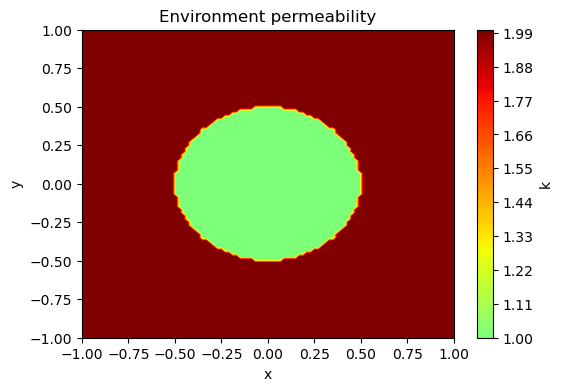

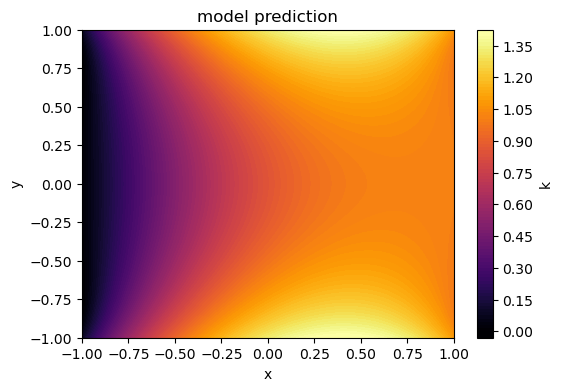

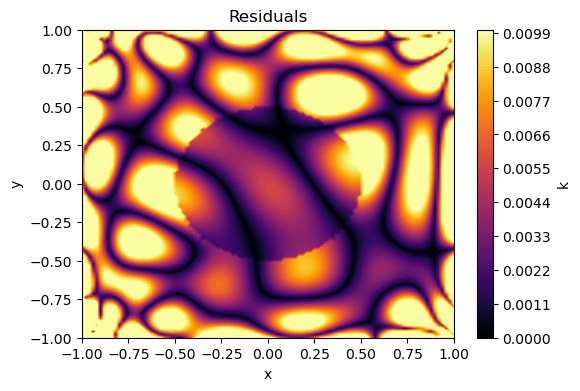

In [ ]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=0,
    vmax=2,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmin = 0
plot_ctx.vmax = 1.4
plot_ctx.colour_map = 'inferno'
plot_ctx.titles = ['model prediction']

utils.plot_function_on_2d_cube([lambda x: model(x)], plot_ctx)

plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0
plot_ctx.titles = ["Residuals"]

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model)), 0.0, 0.01)], plot_ctx)